In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from tqdm import tqdm

# Asegúrate de que la carpeta del proyecto está en el path (si ejecutas desde Colab/local)
# Si tu notebook está en la raíz del repo y tu clase está en agents/AgentSarsaSemiGradNStep.py,
# esto debería funcionar sin tocar nada. Si no, ajusta el path.
if "" not in sys.path:
    sys.path.insert(0, "")

# Importa la clase desde tu .py (ajusta el import si tu fichero/clase se llaman distinto)
from agents.AgentSARSASemiGrad import AgentSarsaSemiGrad


In [2]:
def plot_success_ratio(list_stats_success):
    successes = np.array(list_stats_success)

    # media acumulada
    cumulative_ratio = np.cumsum(successes) / np.arange(1, len(successes) + 1)

    plt.figure(figsize=(6, 3))
    plt.plot(cumulative_ratio)
    plt.title("Proporción acumulada de éxitos")
    plt.xlabel("Episodio")
    plt.ylabel("Proporción de éxitos")
    plt.grid(True)
    plt.show()


def plot_episode_length(episode_lengths, title="Longitud de episodios"):
    y = np.array(episode_lengths, dtype=float)
    x = np.arange(len(y))

    plt.figure(figsize=(8, 4))
    plt.plot(x, y, label="Steps por episodio")

    plt.title(title)
    plt.xlabel("Episodio")
    plt.ylabel("Steps")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_global_avg(list_stats, title="Media acumulada del return"):
    indices = list(range(len(list_stats)))
    plt.figure(figsize=(8, 4))
    plt.plot(indices, list_stats)
    plt.title(title)
    plt.xlabel("Episodio")
    plt.ylabel("Return medio acumulado")
    plt.grid(True)
    plt.show()


In [3]:
import gymnasium as gym
from tqdm import tqdm

env = gym.make("Acrobot-v1")

n_episodes = 5000
max_steps = 500

# n=1 -> SARSA 1-step (semi-gradiente)
# n>1 -> SARSA n-step (semi-gradiente)
agent = AgentSarsaSemiGrad(
    env,
    n=4,
    epsilon=1.0,
    decay=True,
    decay_c=1000.0,
    discount_factor=0.99,
    alpha=1e-3,
    hidden=128,
    seed=0
)

step_display = max(1, n_episodes // 10)

for episode in tqdm(range(n_episodes)):
    state, info = env.reset()

    # Initialize and store S0 != terminal
    # Select and store A0
    # T <- ∞
    agent.start_episode(state)

    # Loop for t = 0,1,2,...
    t = 0
    while True:
        done_episode = agent.step(t)
        t += 1

        # Seguridad por si algo se alarga
        if t > (max_steps + agent.n + 5):
            break

        if done_episode:
            break

    if episode % step_display == 0 and episode != 0:
        print(f"avg_return: {agent.stats / agent.t:.2f}, epsilon: {agent.epsilon:.4f}")

list_stats, episode_lengths, list_stats_success = agent.get_stats()
env.close()

 10%|█         | 501/5000 [10:37<1:22:40,  1.10s/it]

avg_return: -499.54, epsilon: 1.0000


 20%|██        | 1001/5000 [20:03<1:12:52,  1.09s/it]

avg_return: -499.06, epsilon: 0.9990


 30%|███       | 1501/5000 [27:33<31:11,  1.87it/s]  

...

 80%|████████  | 4001/5000 [44:40<05:14,  3.18it/s]

avg_return: -286.17, epsilon: 0.2499


 90%|█████████ | 4501/5000 [47:32<02:56,  2.83it/s]

avg_return: -270.59, epsilon: 0.2222


100%|██████████| 5000/5000 [50:23<00:00,  1.65it/s]


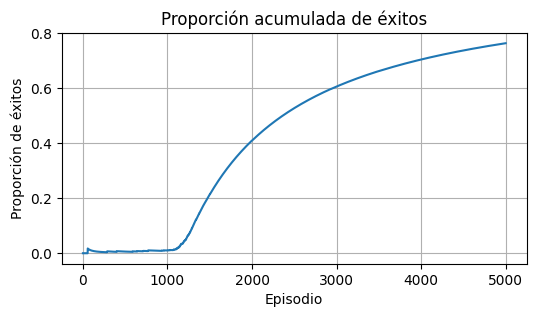

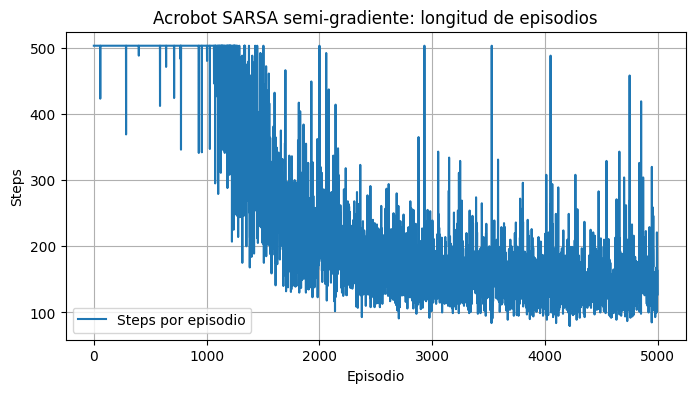

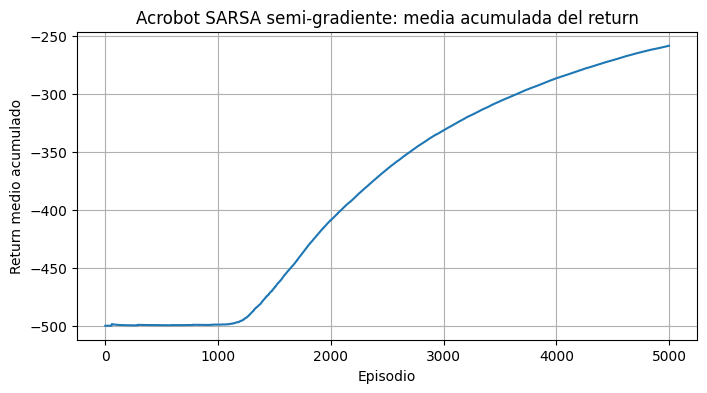

In [4]:
plot_success_ratio(list_stats_success)             
plot_episode_length(episode_lengths, title="Acrobot SARSA semi-gradiente: longitud de episodios")
plot_global_avg(list_stats, title="Acrobot SARSA semi-gradiente: media acumulada del return")
